# Explanatory Data Analysis

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Directories
ROOT_DIR = os.path.abspath("")
DATA_DIR = os.path.join(ROOT_DIR, "data/")
PROCESSED_DIR = os.path.join(ROOT_DIR, "data/processed/")

In [2]:
# Import raw data
x_train = pd.read_csv(DATA_DIR + "X_train.csv")
y_train = pd.read_csv(DATA_DIR + "y_train.csv")
x_test  = pd.read_csv(DATA_DIR + "X_test.csv")

# Join X and y train sets
train = x_train.merge(y_train, on='ID')

### 1. Statistiques descriptives

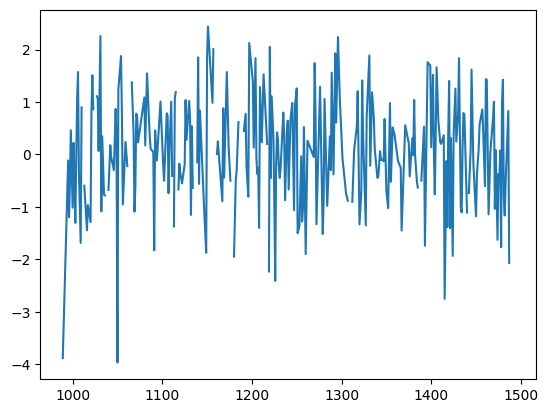

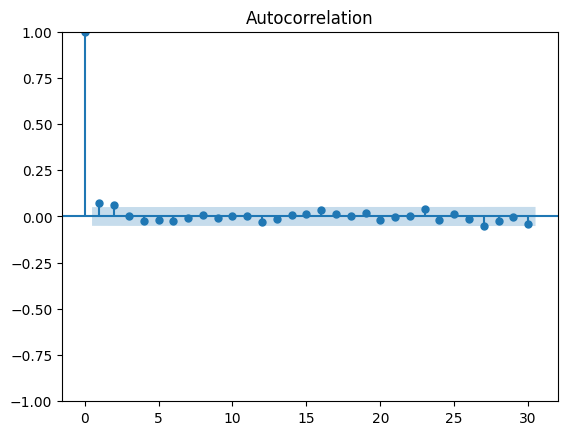

In [3]:
# Vérifier si les données sont interprêtables comme des séries temporelles
train.set_index('DAY_ID', inplace=True)
train.sort_index(inplace=True)

# Plot pour vérifier la saisonnalité (température hiver vs été)
col = 'FR_TEMP'
ctry = 'FR'
df_timeseries_test = x_train[x_train['COUNTRY']==ctry]
df_timeseries_test = df_timeseries_test[col].tail(300)
plt.plot(df_timeseries_test)

# Vérifier l'autocorrélation de la target
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(train['TARGET'], lags=30)
plt.show()

Les données de température ne présentent pas d'effet de saisonalité quand on visualise la série. De plus, la série target ne présente pas d'autocorrélation vraiment significative. Les données ne semblent donc pas ordonnées paar le temps et à intervalle constant.

In [5]:
# Statistics on the train set
train.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,1494.0,1072.759036,618.013179,0.000000,540.250000,1077.500000,1597.500000,2146.000000
DE_CONSUMPTION,1494.0,0.427442,0.673412,-2.265563,-0.037421,0.357061,0.922057,2.033851
FR_CONSUMPTION,1494.0,-0.020032,0.918995,-1.462350,-0.716771,-0.394166,0.650533,3.300640
DE_FR_EXCHANGE,1469.0,-0.145508,0.970226,-2.856874,-0.875213,-0.164287,0.638867,2.634831
FR_DE_EXCHANGE,1469.0,0.145508,0.970226,-2.634831,-0.638867,0.164287,0.875213,2.856874
DE_NET_EXPORT,1370.0,-0.256332,0.957443,-2.464849,-0.977214,-0.306899,0.452252,2.279619
FR_NET_EXPORT,1424.0,-0.072643,1.075830,-2.825331,-0.851500,0.099455,0.794843,1.951516
DE_NET_IMPORT,1370.0,0.256332,0.957443,-2.279619,-0.452252,0.306899,0.977214,2.464849
FR_NET_IMPORT,1424.0,0.072643,1.075830,-1.951516,-0.794843,-0.099455,0.851500,2.825331
DE_GAS,1494.0,0.780699,0.850190,-1.117260,0.134947,0.740006,1.399461,3.118082


In [6]:
# Statistics on issing values
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
print(missing_df[missing_df['missing'] > 0])

                missing   pct
DE_FR_EXCHANGE       25  1.67
FR_DE_EXCHANGE       25  1.67
DE_NET_EXPORT       124  8.30
FR_NET_EXPORT        70  4.69
DE_NET_IMPORT       124  8.30
FR_NET_IMPORT        70  4.69
DE_RAIN              94  6.29
FR_RAIN              94  6.29
DE_WIND              94  6.29
FR_WIND              94  6.29
DE_TEMP              94  6.29
FR_TEMP              94  6.29


Les valeurs manquantes concernent principalement des colonnes propres à un pays (ex: `DE_RAIN` qui n'a pas d'équivalent FR). Cela s'explique par le fait que les observations FR et DE sont dans le même fichier mais ne partagent pas toutes les mêmes variables. Nous allons séparer les deux pays avant la modélisation.

### 2. Distribution de la variable cible

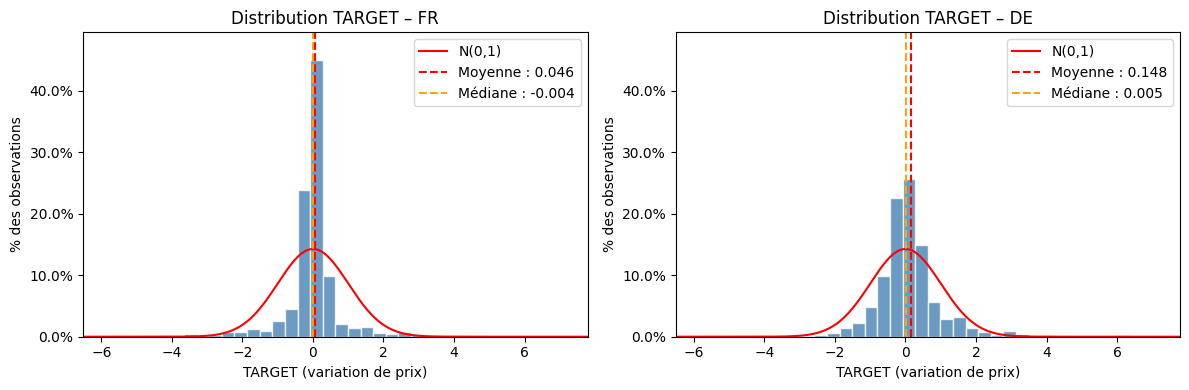

         count      mean       std       min       25%       50%       75%  \
COUNTRY                                                                      
DE       643.0  0.148044  1.047022 -3.075929 -0.324693  0.005057  0.386596   
FR       851.0  0.046026  1.023512 -6.519268 -0.178023 -0.003619  0.174344   

              max  
COUNTRY            
DE       7.138604  
FR       7.786578  


In [4]:
# Target distribution profile by country
from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

all_data = train[train['COUNTRY'].isin(['FR', 'DE'])]['TARGET']
bins = np.linspace(all_data.min(), all_data.max(), 41)

max_pct = 0
for country in ['FR', 'DE']:
    subset = train[train['COUNTRY'] == country]['TARGET']
    weights = np.ones(len(subset)) / len(subset) * 100
    counts, _ = np.histogram(subset, bins=bins, weights=weights)
    max_pct = max(max_pct, counts.max())

x_norm = np.linspace(all_data.min(), all_data.max(), 300)
bin_width = (all_data.max() - all_data.min()) / 40
y_norm = norm.pdf(x_norm, 0, 1) * bin_width * 100

for ax, country in zip(axes, ['FR', 'DE']):
    subset = train[train['COUNTRY'] == country]['TARGET']
    weights = np.ones(len(subset)) / len(subset) * 100
    ax.hist(subset, bins=bins, weights=weights, color='steelblue', edgecolor='white', alpha=0.8)
    ax.plot(x_norm, y_norm, color='red', linewidth=1.5, linestyle='-', label='N(0,1)')
    ax.axvline(subset.mean(), color='red', linestyle='--', label=f'Moyenne : {subset.mean():.3f}')
    ax.axvline(subset.median(), color='orange', linestyle='--', label=f'Médiane : {subset.median():.3f}')
    ax.set_title(f'Distribution TARGET – {country}')
    ax.set_xlabel('TARGET (variation de prix)')
    ax.set_ylabel('% des observations')
    ax.set_xlim(all_data.min(), all_data.max())
    ax.set_ylim(0, max_pct * 1.1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
    ax.legend()

plt.tight_layout()
plt.show()

print(train.groupby('COUNTRY')['TARGET'].describe())

**Ce qui saute aux yeux en premier**, c'est le pic central de la France : près de 45% des observations ont une variation journalière quasiment nulle, contre ~23% pour l'Allemagne. Le marché français est donc beaucoup plus "immobile" au quotidien, ce qui s'explique par la prévisibilité de la production nucléaire — une base stable qui ne dépend ni du vent ni du soleil.

**L'Allemagne est structurellement plus volatile.** La distribution allemande est bien plus étalée, avec un interquartile [−0.32 ; +0.39] contre [−0.18 ; +0.17] pour la France — soit un écart interquartile presque deux fois plus large. La moyenne allemande (0.148) est également bien au-dessus de la médiane (0.005), signe d'une asymétrie droite marquée : des hausses de prix ponctuelles et fortes tirent la moyenne vers le haut, cohérent avec la dépendance allemande au gaz et au charbon lors des pics de demande.

**Les deux distributions sont très piquées par rapport à la N(0,1)** — visible directement sur le graphique : le pic central dépasse largement la courbe rouge, tandis que les queues passent en dessous. C'est le signe d'une distribution leptokurtique : la plupart des jours, les prix bougent très peu, bien plus souvent qu'une loi normale ne le supposerait. Les chocs existent mais restent ponctuels.

**La queue gauche française est nettement plus épaisse** : le minimum atteint −6.52 contre −3.08 pour l'Allemagne, soit plus du double en valeur absolue. Ces chocs baissiers extrêmes correspondent vraisemblablement à des épisodes de surproduction — forte production nucléaire combinée à un pic ENR et une demande faible. À l'inverse, les maxima sont comparables (FR : +7.79, DE : +7.14), ce qui montre que les deux pays sont exposés de façon similaire aux hausses extrêmes.

**Pour la modélisation**, cela confirme deux choses : premièrement, modéliser FR et DE séparément est indispensable car leurs dynamiques sont fondamentalement différentes, aussi bien en dispersion qu'en asymétrie. Deuxièmement, le Spearman est bien la bonne métrique — un RMSE serait écrasé par ces quelques jours extrêmes et ne reflèterait pas la qualité réelle du modèle sur les jours ordinaires.

### 3. Corrélations avec la variable cible

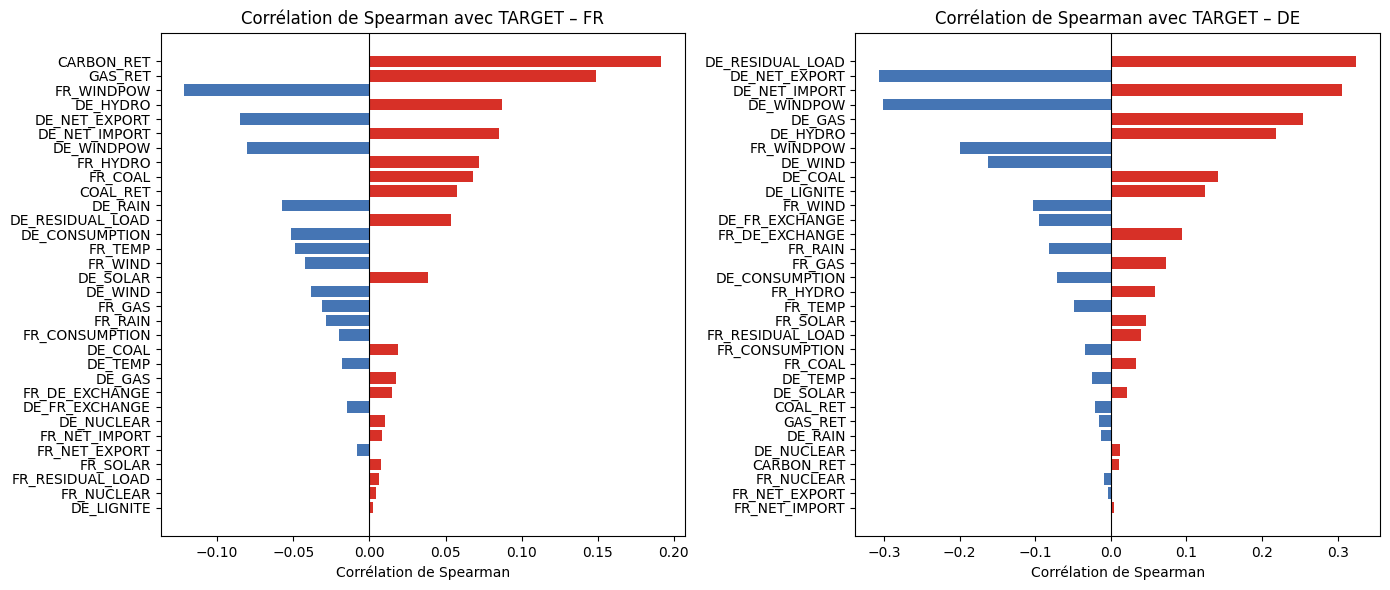

In [19]:
# Correlations between features and target
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['ID', 'DAY_ID', 'TARGET']]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, country in zip(axes, ['FR', 'DE']):
    subset = train[train['COUNTRY'] == country]
    corr = subset[numeric_cols + ['TARGET']].corr(method='spearman')['TARGET'].drop('TARGET')
    corr_sorted = corr.abs().sort_values(ascending=True)
    corr_sorted_signed = corr[corr_sorted.index]
    colors = ['#d73027' if v > 0 else '#4575b4' for v in corr_sorted_signed]
    ax.barh(corr_sorted_signed.index, corr_sorted_signed.values, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Corrélation de Spearman avec TARGET – {country}')
    ax.set_xlabel('Corrélation de Spearman')

plt.tight_layout()
plt.show()

Ces graphiques montrent la corrélation de Spearman entre chaque variable explicative et la TARGET, séparément pour FR et DE.

**Plusieurs enseignements ressortent.**

**Pour la France**, les corrélations sont globalement faibles (toutes inférieures à 0.20 en valeur absolue). Les variables les plus corrélées positivement sont `CARBON_RET` (~0.20) et `GAS_RET` (~0.15) — cohérent avec le merit order : quand le carbone et le gaz sont chers, les prix à terme montent. `DE_HYDRO` et `DE_NET_IMPORT` ressortent également positivement, ce qui reflète l'interconnexion franco-allemande. En revanche, `FR_WINDPOW` est négativement corrélé : plus la production éolienne française est élevée, plus les prix baissent.

**Pour l'Allemagne**, les corrélations sont nettement plus fortes (jusqu'à ~0.32). `DE_RESIDUAL_LOAD` domine largement — c'est la charge résiduelle après ENR, c'est-à-dire exactement ce que les centrales thermiques doivent couvrir. Plus elle est élevée, plus les centrales à gaz et au charbon sont sollicitées et plus les prix montent. `DE_WINDPOW` est fortement négatif : l'éolien allemand est un driver baissier majeur des prix.

**La différence de magnitude entre les deux pays est frappante** : les corrélations allemandes sont presque deux fois plus fortes que les françaises. Cela suggère que les variables disponibles dans le dataset expliquent mieux la dynamique allemande que française — probablement parce que le mix français, dominé par le nucléaire (peu variable et peu corrélé aux conditions météo), est plus difficile à capter avec ces seules variables.

### 4. Évolution temporelle

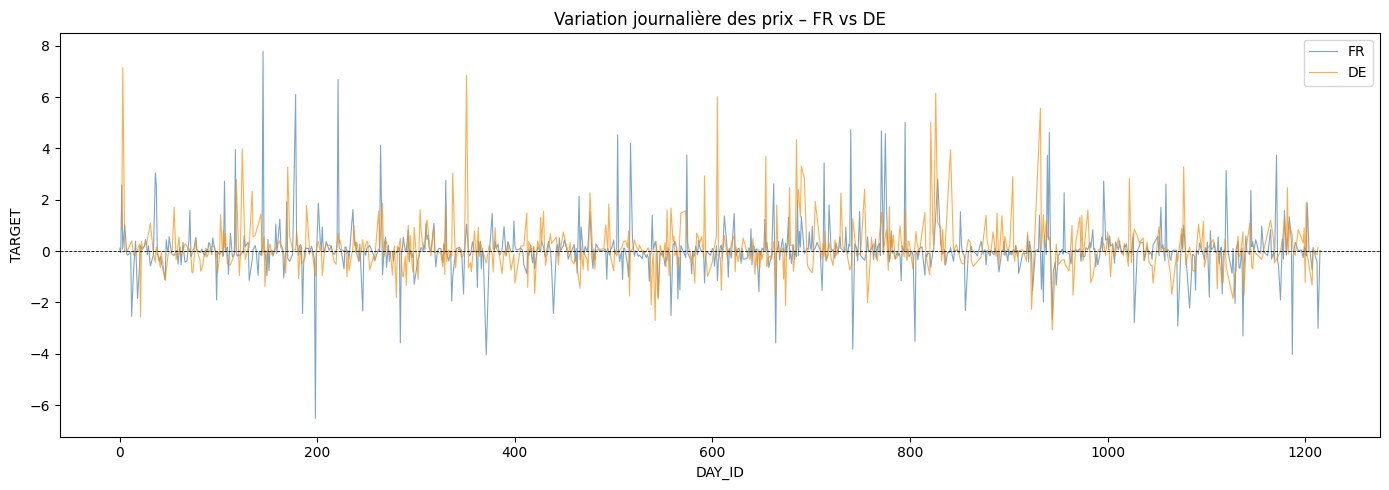

In [20]:
# Historical target series by country
fig, ax = plt.subplots(figsize=(14, 5))

colors = {'FR': 'steelblue', 'DE': 'darkorange'}

for country in ['FR', 'DE']:
    subset = train[train['COUNTRY'] == country].sort_values('DAY_ID')
    ax.plot(subset.index, subset['TARGET'], linewidth=0.8, color=colors[country], alpha=0.7, label=country)

ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax.set_title('Variation journalière des prix – FR vs DE')
ax.set_ylabel('TARGET')
ax.set_xlabel('DAY_ID')
ax.legend()

plt.tight_layout()
plt.show()

Ces graphiques montrent l'évolution temporelle de la variation journalière des prix sur l'ensemble de la période d'observation (~1250 jours, soit un peu plus de 3 ans).

**Le régime de volatilité change clairement dans le temps.** Sur les deux pays, on observe une période de forte agitation entre les DAY_ID ~100 et ~450, qui correspond vraisemblablement à la crise énergétique de 2022 (invasion de l'Ukraine, flambée des prix du gaz). Les pics les plus extrêmes se concentrent sur cette fenêtre. Avant et après, la série est nettement plus calme et resserrée autour de zéro.

**La France présente des chocs plus asymétriques.** Les pics haussiers peuvent atteindre +7/+8, mais surtout la queue baissière est plus profonde (-6 environ, visible vers DAY_ID ~350). Ces effondrements ponctuels sont caractéristiques d'épisodes de surproduction soudaine — typiquement une nuit de fort vent ou un week-end de printemps où la demande chute mais que le nucléaire continue de tourner à plein régime.

**L'Allemagne est plus "bruitée" en dehors des crises.** Même sur les périodes calmes (DAY_ID > 600), la série allemande oscille plus régulièrement autour de zéro, avec des variations positives et négatives plus fréquentes et plus symétriques. C'est cohérent avec l'intermittence des ENR qui crée une volatilité de fond permanente.

**Une implication directe pour la modélisation** : la non-stationnarité de la variance (les périodes de crise sont bien plus volatiles) va complexifier l'apprentissage. Un modèle entraîné sur l'ensemble de la période devra gérer des régimes très différents — c'est précisément ce que le clustering de la partie 6 cherche à capturer en identifiant ces régimes de marché distincts.